# Validate chip-sales estimates against the published website data

The model notebooks and modules in this repo write per-chip and cumulative estimates to `csv_export/`, which feed the public dataset at [epoch.ai/data/ai-chip-sales](https://epoch.ai/data/ai-chip-sales). This notebook wraps `validate_chip_sales.py`: it downloads the currently published dataset (in memory, nothing is written to disk), compares it cell by cell against the local CSVs for **every configured designer**, and reports where the two disagree.

Each compared cell is classified by its percent difference: **ok** (within 1%), **minor** (1–10%), or **major** (over 10%, worth investigating). The same checks run from the command line via `python validate_chip_sales.py --designer all`, or as part of `python run_chip_model.py <family>`.

In [1]:
import pandas as pd
from IPython.display import display, Markdown

from validate_chip_sales import (
    DESIGNER_CONFIGS,
    fetch_website_tables,
    validate_designer,
    verdict,
    coverage_summary,
    metric_summary,
    pct_diff_table,
    plot_cumulative_timeseries,
)

web_tables = fetch_website_tables()
all_results = {designer: validate_designer(designer, web_tables) for designer in DESIGNER_CONFIGS}

pd.DataFrame([{"designer": designer, **verdict(results)} for designer, results in all_results.items()])

Loaded 3 published tables (24,484 bytes)


,designer,major_cells,unmatched_rows,ok
0,nvidia,6,0,False
1,google,0,0,True


## Row coverage and run timestamps

Do the two sides contain the same rows, and do they come from the same model run? If `same run` is False, the published table was generated from a different (usually older) run, so value differences below are expected rather than alarming.

In [2]:
frames = []
for designer, results in all_results.items():
    df = coverage_summary(results)
    df.insert(0, "designer", designer)
    frames.append(df)
pd.concat(frames, ignore_index=True)

,designer,table,rows matched,local only,website only,local run,website run,same run
0,nvidia,Quarterly timelines by chip,50,0,0,06-03-2026 17:56 (x50),"01-28-2026 12:48 (x44), 06-03-2026 17:56 (x4),...",False
1,nvidia,Cumulative timelines by chip,85,0,0,06-03-2026 17:56 (x85),06-03-2026 17:56 (x85),True
2,nvidia,Cumulative totals by designer,18,0,0,06-03-2026 17:56 (x18),06-03-2026 17:56 (x18),True
3,google,Quarterly timelines by chip,35,0,0,06-11-2026 14:09 (x35),06-11-2026 12:02 (x35),False
4,google,Cumulative timelines by chip,65,0,0,06-11-2026 14:09 (x65),06-11-2026 12:02 (x65),False
5,google,Cumulative totals by designer,15,0,0,06-11-2026 14:09 (x15),06-11-2026 12:02 (x15),False


## Per-metric summary

How well each metric agrees, per designer and table: counts of ok/minor/major cells, the average signed difference (a consistent positive or negative bias means the local model has shifted in one direction), and the typical and worst absolute differences.

In [3]:
frames = []
for designer, results in all_results.items():
    df = metric_summary(results)
    df.insert(0, "designer", designer)
    frames.append(df)
pd.concat(frames, ignore_index=True).round(2)

,designer,table,metric,n,ok,minor,major,mean_signed_pct,mean_abs_pct,max_abs_pct
0,nvidia,Quarterly timelines by chip,Units median,50,48,1,1,0.86,1.16,43.67
1,nvidia,Quarterly timelines by chip,Units p5,50,39,10,1,0.27,2.04,44.13
2,nvidia,Quarterly timelines by chip,Units p95,50,41,8,1,1.13,1.91,44.37
3,nvidia,Quarterly timelines by chip,H100e median,50,48,1,1,0.86,1.16,43.67
4,nvidia,Quarterly timelines by chip,H100e p5,50,39,10,1,0.26,2.04,44.13
5,nvidia,Quarterly timelines by chip,H100e p95,50,41,8,1,1.13,1.91,44.37
6,nvidia,Cumulative timelines by chip,Units median,85,85,0,0,0.00,0.00,0.00
7,nvidia,Cumulative timelines by chip,Units p5,85,85,0,0,0.00,0.00,0.00
8,nvidia,Cumulative timelines by chip,Units p95,85,85,0,0,0.00,0.00,0.00
9,nvidia,Cumulative timelines by chip,H100e median,85,85,0,0,0.00,0.00,0.00


## Percent differences by quarter

Where the differences actually are — by chip for the two chip-level comparisons, and by metric for the designer totals. For the cumulative tables, a column means the total *through* that quarter.

How to read a cell:

- a **number** is the percent difference (local vs website)
- `-` means neither dataset has that cell (e.g. quarters before a chip launched)
- `local only` / `website only` flag rows that exist on just one side — these also show up in the coverage counts above
- `no data` means the row matched but the value is blank on one side

When every cell in a table is within tolerance and nothing is one-sided, a confirmation line is printed instead of leaving you to scan the grid.

In [4]:
for designer, results in all_results.items():
    display(Markdown(f"### {designer}"))
    display(Markdown("**Quarterly timelines — median units per chip and quarter**"))
    display(pct_diff_table(results, "timelines_by_chip"))
    display(Markdown("**Cumulative by chip — median units per chip, through each quarter**"))
    display(pct_diff_table(results, "cumulative_by_chip"))
    display(Markdown("**Designer totals — every metric, through each quarter**"))
    display(pct_diff_table(results, "cumulative_by_designer", metric=None))

### nvidia

**Quarterly timelines — median units per chip and quarter**

quarter,Q1 2022,Q2 2022,Q3 2022,Q4 2022,Q1 2023,Q2 2023,Q3 2023,Q4 2023,Q1 2024,Q2 2024,Q3 2024,Q4 2024,Q1 2025,Q2 2025,Q3 2025,Q4 2025,Q1 2026,Q2 2026
chip,,,,,,,,,,,,,,,,,,
A100,43.7,0.2,0.2,0.4,0.4,0.3,0.1,-0.1,-,-,-,-,-,-,-,-,-,-
A800,-,-,-,0.1,0.2,0.6,0.4,0.2,-,-,-,-,-,-,-,-,-,-
B200,-,-,-,-,-,-,-,-,-,-,-,-0.2,-0.3,-0.4,-0.3,0.3,0.0,0.0
B300,-,-,-,-,-,-,-,-,-,-,-,-,-,-0.1,0.1,-0.2,0.0,0.0
H100,-,-,0.2,0.0,0.2,0.4,0.2,0.3,0.3,0.3,0.4,0.0,0.0,0.4,0.4,0.4,-,-
H20,-,-,-,-,-,-,-,-,-0.3,-0.3,-0.8,-0.3,-0.2,-0.2,-0.3,-,-,-
H800,-,-,-,-,-0.7,-1.1,-0.8,-0.7,-,-,-,-,-,-,-,-,-,-


**Cumulative by chip — median units per chip, through each quarter**

Cumulative timelines by chip: all 85 Units median cells match within the 1.0% tolerance; no one-sided rows


...

Cumulative timelines by chip: all 65 Units median cells match within the 1.0% tolerance; no one-sided rows


quarter,Q1 2023,Q2 2023,Q3 2023,Q4 2023,Q1 2024,Q2 2024,Q3 2024,Q4 2024,Q1 2025,Q2 2025,Q3 2025,Q4 2025,Q1 2026,Q2 2026
chip,,,,,,,,,,,,,,
TPU v4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TPU v4i,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TPU v5e,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TPU v5p,-,-,-,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TPU v6e,-,-,-,-,-,-,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TPU v7,-,-,-,-,-,-,-,-,-,-,0.0,0.0,0.0,0.0


**Designer totals — every metric, through each quarter**

Cumulative totals by designer: all 135 cells match within the 1.0% tolerance; no one-sided rows


quarter,Q4 2022,Q1 2023,Q2 2023,Q3 2023,Q4 2023,Q1 2024,Q2 2024,Q3 2024,Q4 2024,Q1 2025,Q2 2025,Q3 2025,Q4 2025,Q1 2026,Q2 2026
metric,,,,,,,,,,,,,,,
Units median,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Units p5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Units p95,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
H100e median,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
H100e p5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
H100e p95,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Power MW median,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Power MW p5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Power MW p95,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Cumulative totals over time

Local vs published cumulative totals per designer. The published values are drawn as a wide orange line underneath the local blue line, so where the two agree the orange shows as a halo around the blue; the shaded band is the local 5th–95th percentile range.

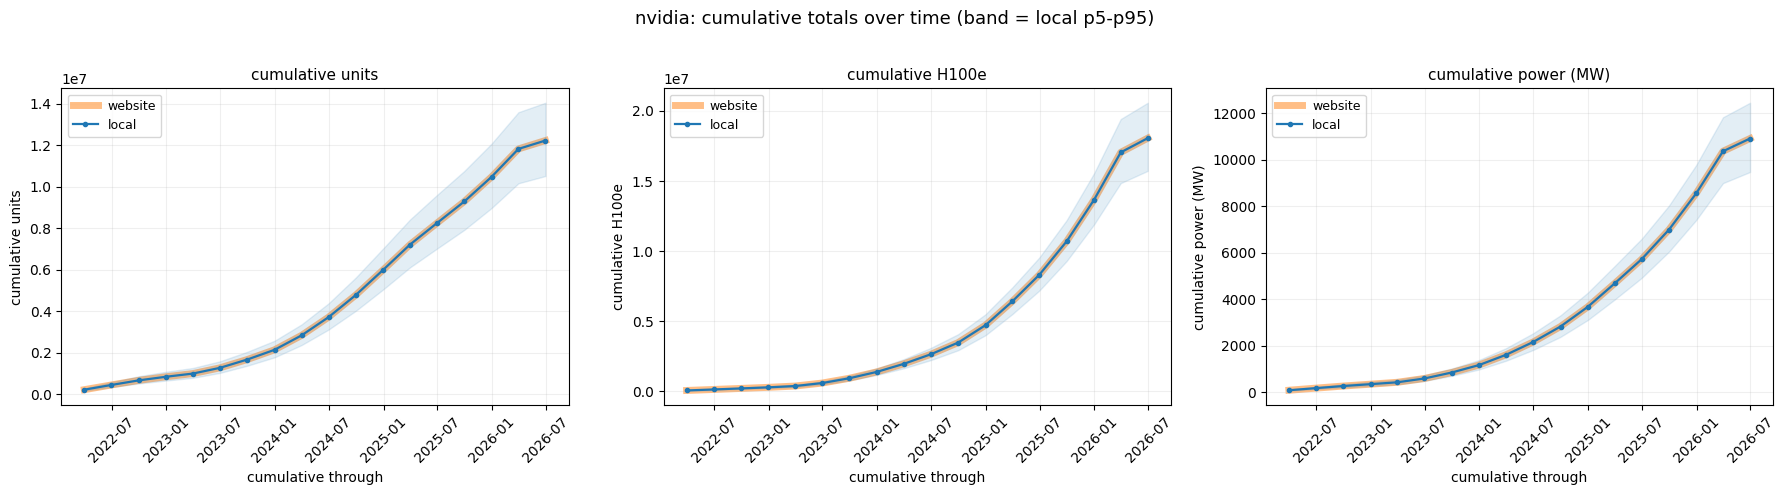

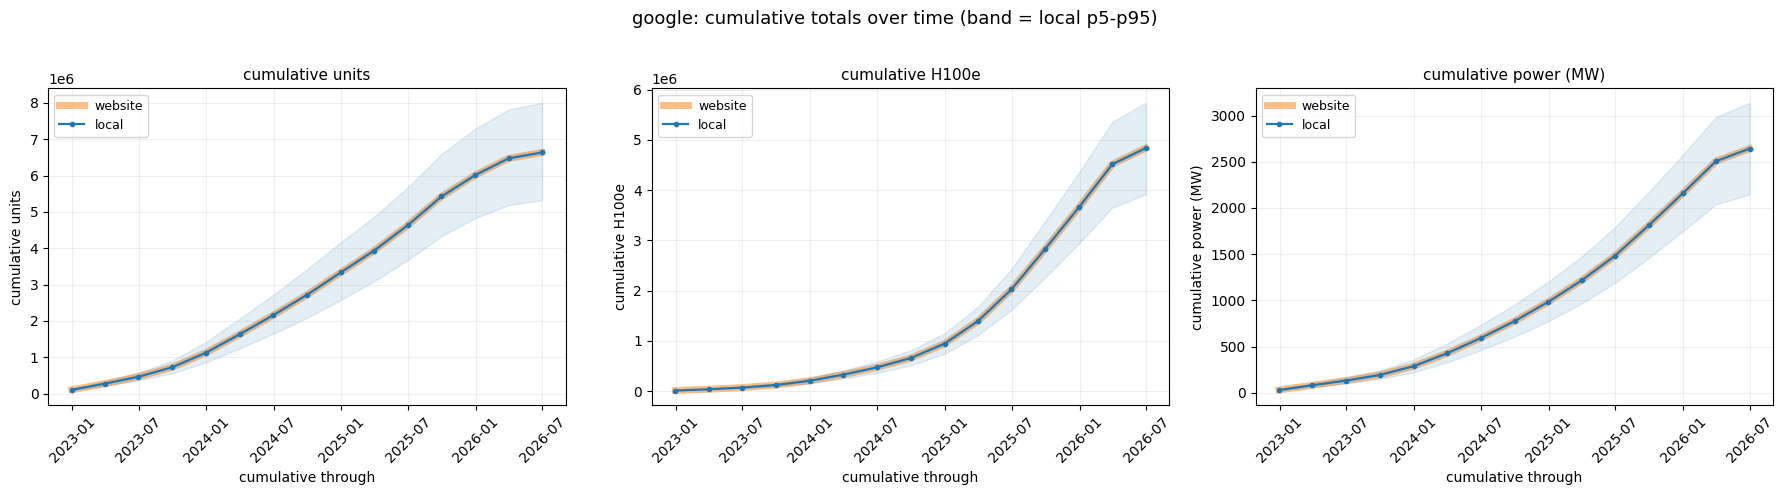

In [5]:
for designer, results in all_results.items():
    fig = plot_cumulative_timeseries(results, designer)
    if fig is None:
        print(f"{designer}: no matched designer-totals rows to plot (see row coverage above)")